# Tripeptide Classification: Identifying Missing Amino Acids

This notebook demonstrates a neural network classifier that predicts which amino acid is "missing" when comparing a tripeptide spectrum to a dipeptide spectrum.

## Task Overview
- **Input**: Paired spectra (tripeptide XYZ, dipeptide XY) - both 1D signals of length 1023, normalized [0,1]
- **Output**: Predict Z (the third amino acid in the tripeptide)
- **Example**: For (DFS spectrum, DF spectrum) → predict S

## Available Data
- 7 valid tripeptide-dipeptide pairs with sufficient data
- 3 target classes: A (Alanine), F (Phenylalanine), S (Serine)

## Imports and Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

Using device: cuda


## Constants and Mappings

In [2]:
# Target amino acid classes (3 classes for tripeptide task)
AMINO_ACID_CODES = ['A', 'F', 'S']
CODE_TO_IDX = {code: idx for idx, code in enumerate(AMINO_ACID_CODES)}
IDX_TO_CODE = {idx: code for code, idx in CODE_TO_IDX.items()}

# Full names for display
CODE_TO_NAME = {
    'A': 'Alanine',
    'D': 'Aspartic acid',
    'F': 'Phenylalanine',
    'G': 'Glycine',
    'R': 'Arginine',
    'S': 'Serine'
}

# Minimum spectra threshold
MIN_SPECTRA = 50

print(f'Target classes: {AMINO_ACID_CODES}')
print(f'Class mapping: {CODE_TO_IDX}')

Target classes: ['A', 'F', 'S']
Class mapping: {'A': 0, 'F': 1, 'S': 2}


## Data Loading

In [3]:
# Data directories
tripeptide_dir = Path('./data/processed/tripeptides')
dipeptide_dir = Path('./data/processed/dipeptides')

# Load tripeptide data
tripeptide_data = {}
print('Loading tripeptide data...')
for folder in sorted(tripeptide_dir.iterdir()):
    if folder.is_dir():
        clean_data_path = folder / 'clean_data.npz'
        if clean_data_path.exists():
            data = np.load(clean_data_path, allow_pickle=True)
            intensities = data['intensities']
            n_spectra = intensities.shape[0]
            if n_spectra >= MIN_SPECTRA:
                tripeptide_data[folder.name] = intensities
                print(f'  {folder.name}: {n_spectra} spectra')
            else:
                print(f'  {folder.name}: {n_spectra} spectra (skipped, < {MIN_SPECTRA})')

print(f'\nLoaded {len(tripeptide_data)} tripeptides with >= {MIN_SPECTRA} spectra')

Loading tripeptide data...
  ARS: 29 spectra (skipped, < 50)
  ASF: 707 spectra
  DFA: 264 spectra
  DFS: 1301 spectra
  DRF: 147 spectra
  FDR: 250 spectra
  FGA: 293 spectra
  FGS: 838 spectra
  FSA: 660 spectra
  FSG: 35 spectra (skipped, < 50)
  GAR: 189 spectra
  RSA: 9 spectra (skipped, < 50)
  RSF: 82 spectra
  SDF: 103 spectra
  SGF: 272 spectra
  SRA: 1470 spectra

Loaded 13 tripeptides with >= 50 spectra


In [4]:
# Load dipeptide data
dipeptide_data = {}
print('Loading dipeptide data...')
for folder in sorted(dipeptide_dir.iterdir()):
    if folder.is_dir():
        clean_data_path = folder / 'clean_data.npz'
        if clean_data_path.exists():
            data = np.load(clean_data_path, allow_pickle=True)
            intensities = data['intensities']
            n_spectra = intensities.shape[0]
            if n_spectra >= MIN_SPECTRA:
                dipeptide_data[folder.name] = intensities
                print(f'  {folder.name}: {n_spectra} spectra')
            else:
                print(f'  {folder.name}: {n_spectra} spectra (skipped, < {MIN_SPECTRA})')

print(f'\nLoaded {len(dipeptide_data)} dipeptides with >= {MIN_SPECTRA} spectra')

Loading dipeptide data...
  AD: 397 spectra
  AF: 1246 spectra
  AG: 1446 spectra
  AR: 188 spectra
  AS: 31 spectra (skipped, < 50)
  DA: 318 spectra
  DF: 1372 spectra
  DG: 483 spectra
  DR: 586 spectra
  DS: 141 spectra
  FA: 15 spectra (skipped, < 50)
  FD: 226 spectra
  FG: 1432 spectra
  FR: 347 spectra
  FS: 570 spectra
  GA: 58 spectra
  GD: 732 spectra
  GF: 1476 spectra
  GR: 859 spectra
  RA: 209 spectra
  RD: 446 spectra
  RF: 196 spectra
  RG: 439 spectra
  RS: 102 spectra
  SA: 181 spectra
  SD: 14 spectra (skipped, < 50)
  SF: 190 spectra
  SG: 44 spectra (skipped, < 50)
  SR: 205 spectra

Loaded 25 dipeptides with >= 50 spectra


## Dataset Class

In [5]:
class TripeptidePairDataset(Dataset):
    """Dataset for tripeptide-dipeptide pairs.
    
    For each tripeptide XYZ:
    - Input 1: spectrum from tripeptide XYZ
    - Input 2: spectrum from dipeptide XY (first two letters)
    - Label: index of Z (third letter) - the "missing" amino acid
    
    Args:
        tripeptide_data: Dict mapping tripeptide names to spectra arrays
        dipeptide_data: Dict mapping dipeptide names to spectra arrays
        samples_per_pair: Max samples per tripeptide-dipeptide pair (None for all)
        max_samples_per_class: Max total samples per target class for balancing (None for all)
    """
    
    def __init__(self, tripeptide_data, dipeptide_data, samples_per_pair=None, max_samples_per_class=None):
        self.pairs = []  # List of (tripeptide_spectrum, dipeptide_spectrum, label)
        self.pair_info = []  # For debugging: (tripeptide_name, dipeptide_name, target_code)
        
        # First pass: collect all pairs grouped by target class
        class_pairs = {i: [] for i in range(len(AMINO_ACID_CODES))}
        
        for tripeptide_name, tripeptide_spectra in tripeptide_data.items():
            xy = tripeptide_name[:2]  # XY in XYZ (dipeptide input)
            z = tripeptide_name[2]    # Z in XYZ (target to predict)
            
            # Skip if dipeptide data not available
            if xy not in dipeptide_data:
                print(f'  Skipping {tripeptide_name}: dipeptide {xy} not available')
                continue
            
            # Skip if target class not in our label set
            if z not in CODE_TO_IDX:
                print(f'  Skipping {tripeptide_name}: target {z} not in class set')
                continue
            
            dipeptide_spectra = dipeptide_data[xy]
            label = CODE_TO_IDX[z]
            
            # Determine number of pairs (without replacement)
            n_tripeptide = len(tripeptide_spectra)
            n_dipeptide = len(dipeptide_spectra)
            n_pairs = min(n_tripeptide, n_dipeptide)
            if samples_per_pair is not None:
                n_pairs = min(n_pairs, samples_per_pair)
            
            # Random sampling without replacement
            tri_indices = np.random.choice(n_tripeptide, n_pairs, replace=False)
            dip_indices = np.random.choice(n_dipeptide, n_pairs, replace=False)
            
            for ti, di in zip(tri_indices, dip_indices):
                class_pairs[label].append((
                    tripeptide_spectra[ti],
                    dipeptide_spectra[di],
                    label,
                    (tripeptide_name, xy, z)
                ))
        
        # Second pass: balance classes if max_samples_per_class is specified
        for label, pairs in class_pairs.items():
            if len(pairs) == 0:
                continue
                
            # Shuffle pairs for this class
            np.random.shuffle(pairs)
            
            # Limit samples per class if specified
            if max_samples_per_class is not None and len(pairs) > max_samples_per_class:
                pairs = pairs[:max_samples_per_class]
            
            # Add to final dataset
            for tri, dip, lbl, info in pairs:
                self.pairs.append((tri, dip, lbl))
                self.pair_info.append(info)
        
        # Shuffle the final dataset
        combined = list(zip(self.pairs, self.pair_info))
        np.random.shuffle(combined)
        self.pairs, self.pair_info = zip(*combined) if combined else ([], [])
        self.pairs = list(self.pairs)
        self.pair_info = list(self.pair_info)
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        tri, dip, label = self.pairs[idx]
        return (
            torch.tensor(tri, dtype=torch.float32),
            torch.tensor(dip, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long)
        )
    
    def get_labels(self):
        """Return all labels for stratified splitting."""
        return [p[2] for p in self.pairs]
    
    def get_class_distribution(self):
        """Return class distribution."""
        labels = self.get_labels()
        unique, counts = np.unique(labels, return_counts=True)
        return {IDX_TO_CODE[u]: c for u, c in zip(unique, counts)}

In [6]:
# Create dataset with balanced classes (82 samples per class - limited by RSF)
print('Creating paired dataset with balanced classes...')
dataset = TripeptidePairDataset(
    tripeptide_data, 
    dipeptide_data, 
    samples_per_pair=None,
    max_samples_per_class=82  # Balance all classes to 82 samples (limited by RSF)
)
print(f'\nTotal samples: {len(dataset)}')

# Show class distribution
class_dist = dataset.get_class_distribution()
print('\nClass distribution (balanced):')
for code, count in sorted(class_dist.items()):
    print(f'  {code} ({CODE_TO_NAME[code]}): {count} samples')

Creating paired dataset with balanced classes...
  Skipping ASF: dipeptide AS not available
  Skipping FDR: target R not in class set
  Skipping GAR: target R not in class set
  Skipping SDF: dipeptide SD not available
  Skipping SGF: dipeptide SG not available

Total samples: 246

Class distribution (balanced):
  A (Alanine): 82 samples
  F (Phenylalanine): 82 samples
  S (Serine): 82 samples


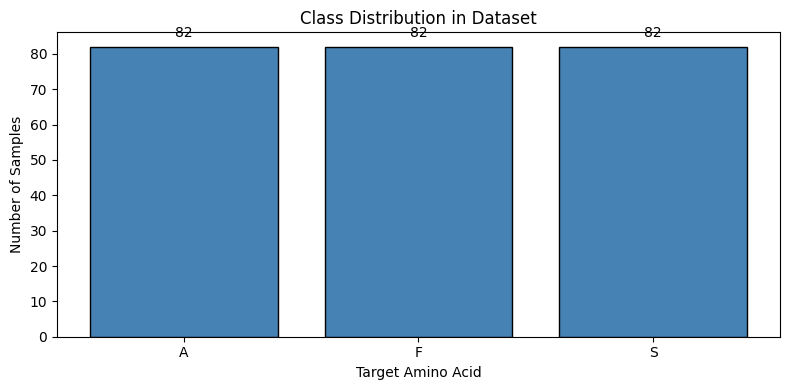

In [7]:
# Visualize class distribution
codes = list(class_dist.keys())
counts = [class_dist[c] for c in codes]

plt.figure(figsize=(8, 4))
plt.bar(codes, counts, color='steelblue', edgecolor='black')
plt.xlabel('Target Amino Acid')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Dataset')
for i, (c, cnt) in enumerate(zip(codes, counts)):
    plt.text(i, cnt + 2, str(cnt), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Train/Validation Split

In [8]:
# Stratified train/val split (80/20)
labels = dataset.get_labels()
indices = list(range(len(dataset)))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(f'Training samples: {len(train_indices)}')
print(f'Validation samples: {len(val_indices)}')

# Create data loaders
batch_size = 16  # Smaller batch size due to smaller dataset

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f'\nBatch size: {batch_size}')
print(f'Training batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')

Training samples: 196
Validation samples: 50

Batch size: 16
Training batches: 13
Validation batches: 4


## Visualize Sample Pairs

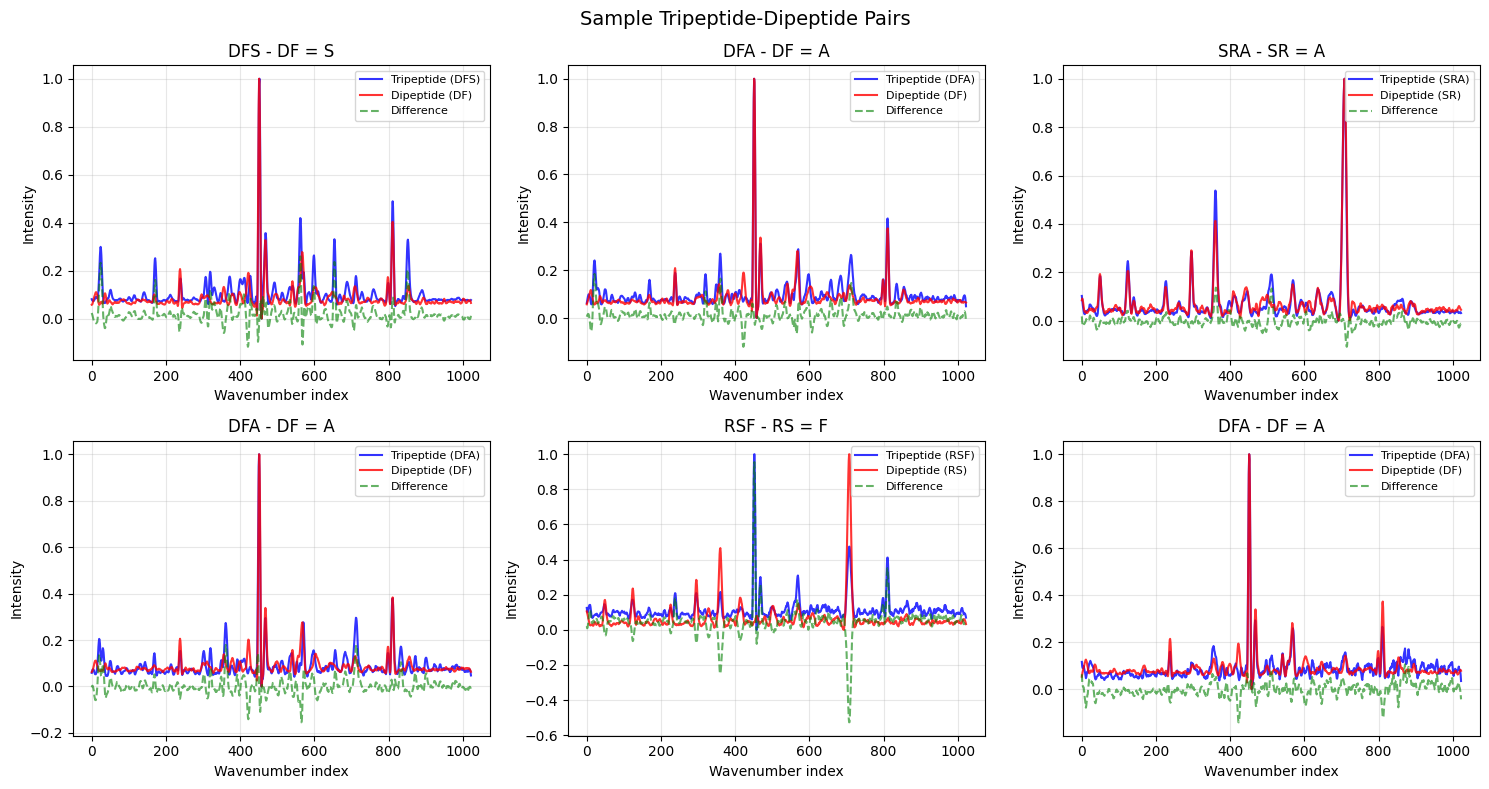

In [20]:
# Visualize a few sample pairs
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sample_indices = np.random.choice(len(dataset), 6, replace=False)

for ax, idx in zip(axes.flat, sample_indices):
    tri, dip, label = dataset[idx]
    tripeptide_name, dipeptide_name, target_aa = dataset.pair_info[idx]
    
    # Plot spectra
    x = np.arange(len(tri))
    ax.plot(x, tri.numpy(), 'b-', label=f'Tripeptide ({tripeptide_name})', alpha=0.8)
    ax.plot(x, dip.numpy(), 'r-', label=f'Dipeptide ({dipeptide_name})', alpha=0.8)
    ax.plot(x, tri.numpy() - dip.numpy(), 'g--', label='Difference', alpha=0.6)
    
    ax.set_title(f'{tripeptide_name} - {dipeptide_name} = {target_aa}')
    ax.set_xlabel('Wavenumber index')
    ax.set_ylabel('Intensity')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sample Tripeptide-Dipeptide Pairs', fontsize=14)
plt.tight_layout()
plt.show()

## Model Architecture

In [9]:
class SimpleDifferentialClassifier(nn.Module):
    """Lightweight classifier for tripeptide pair classification.
    
    Architecture: (S_tripeptide - S_dipeptide) -> CNN -> Transformer -> MLP -> classes
    
    The model learns to classify the "missing" amino acid by analyzing
    the spectral difference between a tripeptide and one of its components.
    
    Args:
        seq_length: Length of input spectra (default: 1023)
        d_model: Embedding dimension (default: 64)
        num_classes: Number of output classes (default: 3)
        dropout: Dropout rate (default: 0.3)
    """
    
    def __init__(self, seq_length=1023, d_model=64, num_classes=3, dropout=0.3):
        super().__init__()
        
        self.seq_length = seq_length
        self.d_model = d_model
        self.num_classes = num_classes
        
        # Feature extractor (CNN)
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(16, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Transformer encoder (lightweight: 1 layer)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=128,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout + 0.2),  # Higher dropout before final layer
            nn.Linear(d_model, num_classes),
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, spectrum_tripeptide, spectrum_dipeptide):
        """Forward pass.
        
        Args:
            spectrum_tripeptide: Tripeptide spectrum (batch, seq_len)
            spectrum_dipeptide: Dipeptide spectrum (batch, seq_len)
        
        Returns:
            Logits of shape (batch, num_classes)
        """
        # Compute spectral difference
        diff = spectrum_tripeptide - spectrum_dipeptide
        diff = diff.unsqueeze(1)  # (batch, 1, seq_len)
        
        # Extract features
        x = self.feature_extractor(diff)  # (batch, d_model, seq_len)
        x = x.transpose(1, 2)  # (batch, seq_len, d_model)
        
        # Encode with transformer
        x = self.encoder(x)  # (batch, seq_len, d_model)
        
        # Global average pooling
        x = x.mean(dim=1)  # (batch, d_model)
        
        # Classify
        logits = self.classifier(x)  # (batch, num_classes)
        
        return logits
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [11]:
# Create model
model = SimpleDifferentialClassifier(
    seq_length=1023,
    d_model=64,
    num_classes=len(AMINO_ACID_CODES),
    dropout=0.3
).to(device)

print(f'Model parameters: {model.count_parameters():,}')
print(f'\nModel architecture:')
print(model)

Model parameters: 43,299

Model architecture:
SimpleDifferentialClassifier(
  (feature_extractor): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(16, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, 

C:\Users\mfarzi\miniconda3\envs\spectra\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## Training

In [12]:
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, patience=20):
    """Train the model with early stopping.
    
    Args:
        model: PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader
        epochs: Maximum number of epochs
        lr: Learning rate
        patience: Early stopping patience
    
    Returns:
        Training history dictionary
    """
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }
    
    # Early stopping
    best_val_loss = float('inf')
    best_val_acc = 0
    epochs_without_improvement = 0
    
    # Ensure checkpoint directory exists
    Path('checkpoints').mkdir(exist_ok=True)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        
        for tri, dip, labels in train_loader:
            tri = tri.to(device)
            dip = dip.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(tri, dip)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation phase
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for tri, dip, labels in val_loader:
                tri = tri.to(device)
                dip = dip.to(device)
                labels = labels.to(device)
                
                outputs = model(tri, dip)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = 100. * correct / total
        
        # Update learning rate
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        # Check for improvement
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_without_improvement = 0
            # Save best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
            }, 'checkpoints/tripeptide_classifier_best.pt')
        else:
            epochs_without_improvement += 1
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch {epoch+1:3d}/{epochs}: '
                  f'Train Loss={train_loss:.4f}, '
                  f'Val Loss={val_loss:.4f}, '
                  f'Val Acc={val_acc:.2f}%, '
                  f'LR={current_lr:.2e}')
        
        # Early stopping
        if epochs_without_improvement >= patience:
            print(f'\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
            break
    
    print(f'\nBest validation loss: {best_val_loss:.4f}')
    print(f'Best validation accuracy: {best_val_acc:.2f}%')
    
    return history

In [13]:
# Train the model
print('Starting training...\n')
history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=100,
    lr=0.001,
    patience=20
)

Starting training...

Epoch   1/100: Train Loss=1.0112, Val Loss=1.3720, Val Acc=34.00%, LR=1.00e-03
Epoch  10/100: Train Loss=0.7221, Val Loss=3.8919, Val Acc=38.00%, LR=1.00e-03
Epoch  20/100: Train Loss=0.2294, Val Loss=0.3391, Val Acc=90.00%, LR=5.00e-04
Epoch  30/100: Train Loss=0.1977, Val Loss=0.3091, Val Acc=90.00%, LR=5.00e-04
Epoch  40/100: Train Loss=0.1711, Val Loss=0.1111, Val Acc=96.00%, LR=5.00e-04
Epoch  50/100: Train Loss=0.1982, Val Loss=0.0589, Val Acc=96.00%, LR=5.00e-04
Epoch  60/100: Train Loss=0.1599, Val Loss=0.3070, Val Acc=94.00%, LR=5.00e-04
Epoch  70/100: Train Loss=0.1812, Val Loss=0.2103, Val Acc=94.00%, LR=2.50e-04

Early stopping at epoch 77 (no improvement for 20 epochs)

Best validation loss: 0.0401
Best validation accuracy: 98.00%


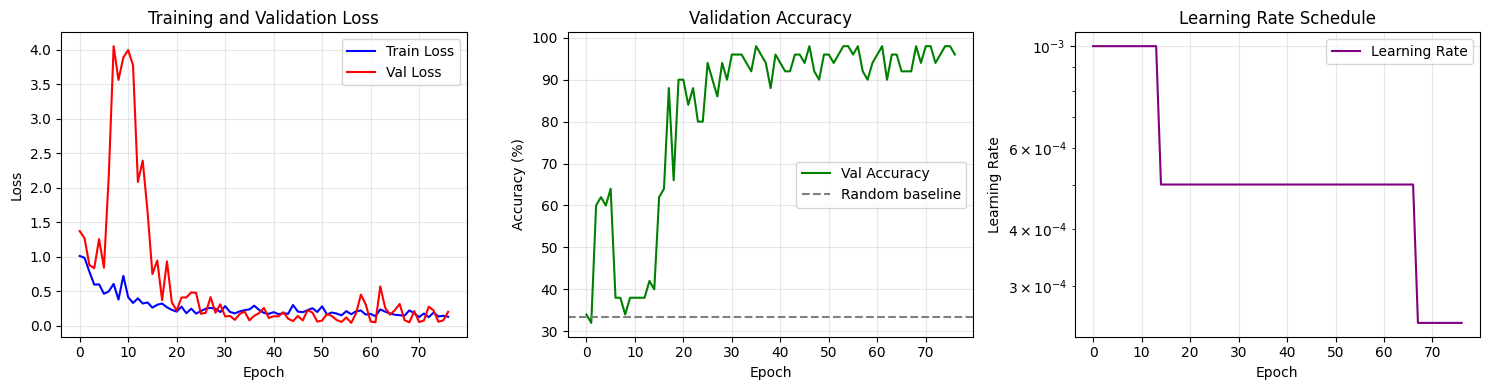

In [14]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[1].axhline(y=100/len(AMINO_ACID_CODES), color='gray', linestyle='--', label='Random baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['lr'], label='Learning Rate', color='purple')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation (Using Dipeptide-Trained Model - 6 Classes)

This section loads the model trained on dipeptide data (6 classes: A, D, F, G, R, S) and evaluates it on the tripeptide validation set.

The tripeptide targets (A, F, S) are mapped to the dipeptide class indices (A=0, F=2, S=5) for evaluation in the full 6-class space. This allows us to see if the model incorrectly predicts D, G, or R for samples.

In [10]:
# Use dipeptide model's 6-class structure for evaluation
DIPEPTIDE_AMINO_ACID_CODES = ['A', 'D', 'F', 'G', 'R', 'S']
DIPEPTIDE_CODE_TO_IDX = {code: idx for idx, code in enumerate(DIPEPTIDE_AMINO_ACID_CODES)}
DIPEPTIDE_IDX_TO_CODE = {idx: code for code, idx in DIPEPTIDE_CODE_TO_IDX.items()}

# Mapping from tripeptide labels (0,1,2 for A,F,S) to dipeptide labels (0,2,5 for A,F,S)
TRIPEPTIDE_TO_DIPEPTIDE_LABEL = {
    CODE_TO_IDX['A']: DIPEPTIDE_CODE_TO_IDX['A'],  # 0 -> 0
    CODE_TO_IDX['F']: DIPEPTIDE_CODE_TO_IDX['F'],  # 1 -> 2
    CODE_TO_IDX['S']: DIPEPTIDE_CODE_TO_IDX['S'],  # 2 -> 5
}

print(f'Dipeptide model classes: {DIPEPTIDE_AMINO_ACID_CODES}')
print(f'Dipeptide class mapping: {DIPEPTIDE_CODE_TO_IDX}')
print(f'\nTripeptide classes: {AMINO_ACID_CODES}')
print(f'Tripeptide class mapping: {CODE_TO_IDX}')
print(f'\nLabel mapping (tripeptide -> dipeptide): {TRIPEPTIDE_TO_DIPEPTIDE_LABEL}')

Dipeptide model classes: ['A', 'D', 'F', 'G', 'R', 'S']
Dipeptide class mapping: {'A': 0, 'D': 1, 'F': 2, 'G': 3, 'R': 4, 'S': 5}

Tripeptide classes: ['A', 'F', 'S']
Tripeptide class mapping: {'A': 0, 'F': 1, 'S': 2}

Label mapping (tripeptide -> dipeptide): {0: 0, 1: 2, 2: 5}


In [11]:
# Create model with dipeptide architecture (6 classes) to load pretrained weights
model = SimpleDifferentialClassifier(
    seq_length=1023,
    d_model=64,
    num_classes=len(DIPEPTIDE_AMINO_ACID_CODES),  # 6 classes to match dipeptide checkpoint
    dropout=0.3
).to(device)

print(f'Model parameters: {model.count_parameters():,}')
print(f'Number of output classes: {len(DIPEPTIDE_AMINO_ACID_CODES)}')

Model parameters: 43,494
Number of output classes: 6


C:\Users\mfarzi\miniconda3\envs\spectra\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [12]:
# Load best model
checkpoint = torch.load('checkpoints/dipeptide_classifier_best.pt')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best validation accuracy: {checkpoint['val_acc']:.2f}%")

Loaded best model from epoch 25
Best validation accuracy: 98.69%


In [13]:
# Evaluate on validation set using dipeptide-trained model (6-class evaluation)
model.eval()
all_predictions = []
all_labels_tripeptide = []  # Original tripeptide labels (0, 1, 2)
all_labels_dipeptide = []   # Mapped to dipeptide space (0, 2, 5)
all_probs = []

with torch.no_grad():
    for tri, dip, labels in val_loader:
        tri = tri.to(device)
        dip = dip.to(device)
        
        outputs = model(tri, dip)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels_tripeptide.extend(labels.numpy())
        # Map tripeptide labels to dipeptide space
        mapped_labels = [TRIPEPTIDE_TO_DIPEPTIDE_LABEL[l.item()] for l in labels]
        all_labels_dipeptide.extend(mapped_labels)
        all_probs.extend(probs.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels_tripeptide = np.array(all_labels_tripeptide)
all_labels_dipeptide = np.array(all_labels_dipeptide)
all_probs = np.array(all_probs)

# Show prediction distribution (6-class space)
print('Prediction distribution (6-class dipeptide space):')
unique, counts = np.unique(all_predictions, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {DIPEPTIDE_IDX_TO_CODE[u]}: {c} predictions')

# Show label distribution (6-class space)
print('\nTrue label distribution (6-class dipeptide space):')
unique, counts = np.unique(all_labels_dipeptide, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {DIPEPTIDE_IDX_TO_CODE[u]}: {c} samples')

# Overall accuracy in 6-class space
accuracy = 100.0 * np.mean(all_predictions == all_labels_dipeptide)
print(f'\nValidation Accuracy (6-class): {accuracy:.2f}%')
print(f'Random baseline (6-class): {100/6:.2f}%')
print(f'Random baseline (3-class): {100/3:.2f}%')

Prediction distribution (6-class dipeptide space):
  A: 4 predictions
  F: 18 predictions
  G: 15 predictions
  R: 2 predictions
  S: 11 predictions

True label distribution (6-class dipeptide space):
  A: 16 samples
  F: 17 samples
  S: 17 samples

Validation Accuracy (6-class): 52.00%
Random baseline (6-class): 16.67%
Random baseline (3-class): 33.33%


In [14]:
# Classification report (6-class space)
# Note: Only A, F, S have true samples; D, G, R may appear in predictions
target_names_6class = [f'{code} ({CODE_TO_NAME[code]})' for code in DIPEPTIDE_AMINO_ACID_CODES]

print('\nClassification Report (6-class, Dipeptide model on Tripeptide data):')
print('=' * 70)
print('Note: True labels only include A, F, S. D, G, R may appear as predictions.')
print()
print(classification_report(
    all_labels_dipeptide, 
    all_predictions, 
    labels=list(range(6)),  # Include all 6 classes
    target_names=target_names_6class, 
    digits=3,
    zero_division=0  # Handle classes with no true samples
))


Classification Report (6-class, Dipeptide model on Tripeptide data):
Note: True labels only include A, F, S. D, G, R may appear as predictions.

                   precision    recall  f1-score   support

      A (Alanine)      1.000     0.250     0.400        16
D (Aspartic acid)      0.000     0.000     0.000         0
F (Phenylalanine)      0.889     0.941     0.914        17
      G (Glycine)      0.000     0.000     0.000         0
     R (Arginine)      0.000     0.000     0.000         0
       S (Serine)      0.545     0.353     0.429        17

         accuracy                          0.520        50
        macro avg      0.406     0.257     0.290        50
     weighted avg      0.808     0.520     0.585        50



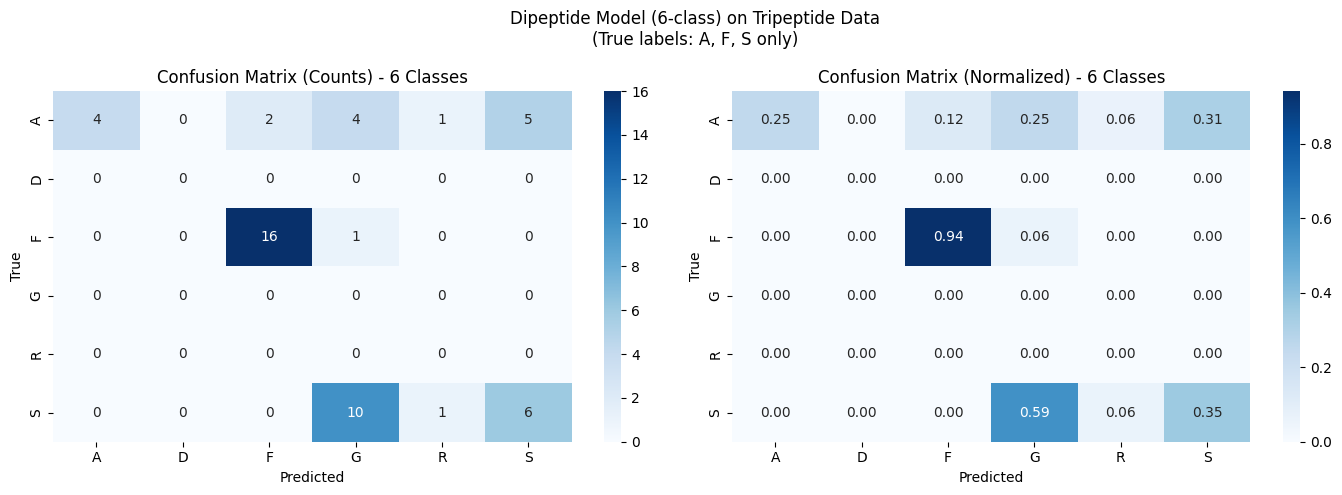

In [15]:
# Confusion matrix (6-class space)
cm = confusion_matrix(all_labels_dipeptide, all_predictions, labels=list(range(6)))

# Normalize only rows that have samples (A, F, S)
cm_normalized = np.zeros_like(cm, dtype=float)
for i in range(6):
    if cm[i].sum() > 0:
        cm_normalized[i] = cm[i].astype('float') / cm[i].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=DIPEPTIDE_AMINO_ACID_CODES, yticklabels=DIPEPTIDE_AMINO_ACID_CODES)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Counts) - 6 Classes')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=DIPEPTIDE_AMINO_ACID_CODES, yticklabels=DIPEPTIDE_AMINO_ACID_CODES)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Normalized) - 6 Classes')

plt.suptitle('Dipeptide Model (6-class) on Tripeptide Data\n(True labels: A, F, S only)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Per-class accuracy (6-class space)
print('\nPer-class accuracy (6-class, Dipeptide model on Tripeptide data):')
for i, code in enumerate(DIPEPTIDE_AMINO_ACID_CODES):
    class_mask = all_labels_dipeptide == i
    n_samples = class_mask.sum()
    if n_samples > 0:
        class_acc = 100.0 * (all_predictions[class_mask] == i).mean()
        print(f'  {code} ({CODE_TO_NAME[code]}): {class_acc:.2f}% ({n_samples} samples)')
    else:
        print(f'  {code} ({CODE_TO_NAME[code]}): N/A (no samples in tripeptide data)')

## Visualize Predictions

In [ ]:
# Visualize some correct and incorrect predictions (6-class space)
correct_mask = all_predictions == all_labels_dipeptide
incorrect_mask = ~correct_mask

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Show 4 correct predictions
correct_indices = np.where(correct_mask)[0]
if len(correct_indices) > 0:
    for ax, idx in zip(axes[0], np.random.choice(correct_indices, min(4, len(correct_indices)), replace=False)):
        val_idx = val_indices[idx]
        tri, dip, label = dataset[val_idx]
        pred = all_predictions[idx]
        true_label = all_labels_dipeptide[idx]
        prob = all_probs[idx][pred]
        
        ax.plot(tri.numpy(), 'b-', label='Tripeptide', alpha=0.8)
        ax.plot(dip.numpy(), 'r-', label='Dipeptide', alpha=0.8)
        ax.plot(tri.numpy() - dip.numpy(), 'g--', label='Difference', alpha=0.6)
        ax.set_title(f'CORRECT: True={DIPEPTIDE_IDX_TO_CODE[true_label]}, Pred={DIPEPTIDE_IDX_TO_CODE[pred]} ({prob:.2f})', 
                     color='green')
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)
else:
    for ax in axes[0]:
        ax.text(0.5, 0.5, 'No correct predictions', ha='center', va='center', fontsize=12)

# Show 4 incorrect predictions
incorrect_indices = np.where(incorrect_mask)[0]
if len(incorrect_indices) > 0:
    for ax, idx in zip(axes[1], np.random.choice(incorrect_indices, min(4, len(incorrect_indices)), replace=False)):
        val_idx = val_indices[idx]
        tri, dip, label = dataset[val_idx]
        pred = all_predictions[idx]
        true_label = all_labels_dipeptide[idx]
        prob = all_probs[idx][pred]
        
        ax.plot(tri.numpy(), 'b-', label='Tripeptide', alpha=0.8)
        ax.plot(dip.numpy(), 'r-', label='Dipeptide', alpha=0.8)
        ax.plot(tri.numpy() - dip.numpy(), 'g--', label='Difference', alpha=0.6)
        ax.set_title(f'INCORRECT: True={DIPEPTIDE_IDX_TO_CODE[true_label]}, Pred={DIPEPTIDE_IDX_TO_CODE[pred]} ({prob:.2f})', 
                     color='red')
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)
else:
    for ax in axes[1]:
        ax.text(0.5, 0.5, 'No incorrect predictions!', ha='center', va='center', fontsize=12)
        ax.set_title('No errors', color='green')

axes[0, 0].set_ylabel('Correct Predictions')
axes[1, 0].set_ylabel('Incorrect Predictions')

plt.suptitle('Dipeptide Model (6-class) Predictions on Tripeptide Validation Set', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated training and evaluation for tripeptide classification, including transfer evaluation using a dipeptide-trained model with full 6-class output.

### Key Results:
- **Task**: Given (tripeptide XYZ, dipeptide XY), predict Z
- **Tripeptide Classes**: 3 amino acids (A, F, S)
- **Dipeptide Model Classes**: 6 amino acids (A, D, F, G, R, S)
- **Model**: SimpleDifferentialClassifier (CNN + Transformer)
- **Architecture**: Spectral difference -> CNN features -> Transformer encoder -> Classification head

### Transfer Evaluation (6-Class):
The evaluation section loads the model trained on dipeptide data (`dipeptide_classifier_best.pt`) with 6 output classes and evaluates it on tripeptide data. 

- Tripeptide labels (A=0, F=1, S=2) are mapped to dipeptide class indices (A=0, F=2, S=5)
- The 6-class confusion matrix shows if the model incorrectly predicts D, G, or R
- This tests whether spectral patterns learned from dipeptide-amino acid differences transfer to tripeptide-dipeptide differences

### Model Design Choices:
1. **Lightweight architecture** due to limited data (~246 samples total)
2. **Spectral difference** as input captures what the amino acid contributes
3. **Single transformer layer** to prevent overfitting
4. **Higher dropout** in classification head for regularization
5. **Class balancing** to 82 samples per class (limited by RSF tripeptide)

### Data Limitations:
- Only 7 valid tripeptide-dipeptide pairs with >= 50 spectra
- Tripeptide targets limited to A, F, S (no D, G, R targets available)
- Smaller dataset compared to dipeptide classification task

### Next Steps:
- Collect more tripeptide data to increase dataset size and cover all 6 classes
- Experiment with data augmentation (noise, scaling)
- Fine-tune the dipeptide model on tripeptide data